In [2]:
"""
train_seq2seq_rnn.py

Instrukcje:
  - Uruchom lokalnie lub w Google Colab (zalecane GPU).
  - Potrzebne paczki: torch, datasets, sacrebleu, numpy, matplotlib, tqdm
    Przykład instalacji:
      pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117   # (lub bez CUDA)
      pip install datasets sacrebleu numpy matplotlib tqdm

Opis:
  - Trenuje dwa modele seq2seq (RNN):
      1) Encoder-Decoder bez atencji
      2) Encoder-Decoder z Luong attention
  - Zbiór: Helsinki-NLP/opus-100, config "en-pl" (kod ładuje pary en-pl, ale model trenujemy pl->en)
  - Tokenizacja: prosty whitespace tokenizer + budowa słownika z ograniczeniem vocab_size
  - Metryka wyboru najlepszych checkpointów: BLEU (sacrebleu)
  - Po każdej epoce ewaluacja na walidacji; na końcu ewaluacja najlepszych checkpointów na teście
"""

import os
import math
import random
import argparse
from collections import Counter
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset  # requires internet when running
import sacrebleu

# ---------------------
# Utilities / Tokenizer
# ---------------------
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class SimpleVocab:
    def __init__(self, max_size=30000, min_freq=2):
        self.max_size = max_size
        self.min_freq = min_freq
        self.freqs = Counter()
        self.itos = []
        self.stoi = {}
    def build(self, texts: List[str]):
        for s in texts:
            toks = simple_tokenize(s)
            self.freqs.update(toks)
        # special tokens first
        specials = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.itos = specials[:]
        most_common = [w for w, c in self.freqs.most_common(self.max_size) if c >= self.min_freq and w not in specials]
        self.itos += most_common
        self.stoi = {w: i for i, w in enumerate(self.itos)}
    def encode(self, text: str, add_sos_eos=True, max_len=None) -> List[int]:
        toks = simple_tokenize(text)
        ids = []
        if add_sos_eos:
            ids.append(self.stoi.get(SOS_TOKEN))
        for t in toks:
            ids.append(self.stoi.get(t, self.stoi.get(UNK_TOKEN)))
            if max_len and len(ids) >= max_len - 1:
                break
        if add_sos_eos:
            ids.append(self.stoi.get(EOS_TOKEN))
        return ids
    def decode(self, ids: List[int]) -> str:
        words = []
        for i in ids:
            if i >= len(self.itos): continue
            w = self.itos[i]
            if w in (PAD_TOKEN, SOS_TOKEN, EOS_TOKEN): continue
            words.append(w)
        return " ".join(words)
    def __len__(self):
        return len(self.itos)

def simple_tokenize(s: str) -> List[str]:
    # Lower + naive split. You can replace with better tokenizer if available.
    return s.strip().lower().split()

# ---------------------
# Dataset wrapper
# ---------------------
class TranslationDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str,str]], src_vocab: SimpleVocab, tgt_vocab: SimpleVocab, max_src_len=100, max_tgt_len=100):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.src_vocab.encode(src, add_sos_eos=True, max_len=self.max_src_len)
        tgt_ids = self.tgt_vocab.encode(tgt, add_sos_eos=True, max_len=self.max_tgt_len)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = [len(s) for s in srcs]
    tgt_lens = [len(t) for t in tgts]
    max_src = max(src_lens)
    max_tgt = max(tgt_lens)
    pad = 0  # index of PAD_TOKEN assumed 0
    src_batch = torch.full((len(batch), max_src), pad, dtype=torch.long)
    tgt_batch = torch.full((len(batch), max_tgt), pad, dtype=torch.long)
    for i, s in enumerate(srcs):
        src_batch[i, :len(s)] = s
    for i, t in enumerate(tgts):
        tgt_batch[i, :len(t)] = t
    return src_batch, torch.tensor(src_lens), tgt_batch, torch.tensor(tgt_lens)

# ---------------------
# Models
# ---------------------
class EncoderRNN(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers=1, dropout=0.1, rnn_type='gru'):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn_type = rnn_type.lower()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.dropout = nn.Dropout(dropout)
        if self.rnn_type == 'gru':
            self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, bidirectional=False, dropout=dropout if n_layers>1 else 0)
        else:
            self.rnn = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, bidirectional=False, dropout=dropout if n_layers>1 else 0)
    def forward(self, src, src_lens):
        # src: [B, T]
        embedded = self.dropout(self.embedding(src))  # [B, T, E]
        # pack padded
        packed = torch.nn.utils.rnn.pack_padded_sequence(embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        outputs, hidden = self.rnn(packed)
        outputs, _ = torch.nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)  # [B, T, H]
        # hidden: for GRU: [n_layers, B, H], for LSTM: (h,c)
        return outputs, hidden

class DecoderRNNNoAttn(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers=1, dropout=0.1, rnn_type='gru'):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn_type = rnn_type.lower()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        if self.rnn_type == 'gru':
            self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0)
        else:
            self.rnn = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0)
        self.out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_step, hidden):
        # input_step: [B] token ids (single time step)
        embedded = self.dropout(self.embedding(input_step).unsqueeze(1))  # [B,1,E]
        output, hidden = self.rnn(embedded, hidden)  # output: [B,1,H]
        output = output.squeeze(1)  # [B,H]
        logits = self.out(output)  # [B, output_dim]
        return logits, hidden

class LuongAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.hid_dim = hid_dim
        self.W = nn.Linear(hid_dim, hid_dim, bias=False)
    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: [B, H] (current decoder hidden)
        # encoder_outputs: [B, T, H]
        # score = decoder_hidden * W * encoder_outputs^T
        # compute energies
        # [B, H] -> [B, H], [B, T, H]
        dec_proj = self.W(decoder_hidden).unsqueeze(2)  # [B, H, 1]
        energies = torch.bmm(encoder_outputs, dec_proj).squeeze(2)  # [B, T]
        if mask is not None:
            energies = energies.masked_fill(mask==0, -1e9)
        attn_weights = torch.softmax(energies, dim=1)  # [B, T]
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights

class DecoderRNNAttn(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers=1, dropout=0.1, rnn_type='gru'):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn_type = rnn_type.lower()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        if self.rnn_type == 'gru':
            self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0)
        else:
            self.rnn = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0)
        self.attn = LuongAttention(hid_dim)
        self.out = nn.Linear(hid_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_step, hidden, encoder_outputs, encoder_mask=None):
        # input_step: [B]
        embedded = self.dropout(self.embedding(input_step).unsqueeze(1))  # [B,1,E]
        output, hidden = self.rnn(embedded, hidden)  # output: [B,1,H]
        output = output.squeeze(1)  # [B,H]
        # get decoder hidden top layer
        if isinstance(hidden, tuple):  # LSTM
            dec_h = hidden[0][-1]  # [B,H]
        else:
            dec_h = hidden[-1]  # [B,H]
        context, attn_weights = self.attn(dec_h, encoder_outputs, mask=encoder_mask)  # [B,H], [B,T]
        concat = torch.cat([output, context], dim=1)  # [B, 2H]
        logits = self.out(concat)  # [B, output_dim]
        return logits, hidden, attn_weights

# ---------------------
# Seq2Seq train / eval
# ---------------------
def create_mask_from_lengths(lengths, max_len=None):
    if max_len is None:
        max_len = lengths.max().item()
    batch_size = lengths.size(0)
    idx = torch.arange(0, max_len, device=lengths.device).unsqueeze(0).expand(batch_size, -1)
    mask = (idx < lengths.unsqueeze(1)).long()
    return mask  # [B, T] 1 for valid tokens

def train_epoch(model_components, dataloader, optimizer, criterion, device, teacher_forcing_ratio=0.5, attn_model=False):
    encoder, decoder = model_components
    encoder.train(); decoder.train()
    total_loss = 0.0
    for src_batch, src_lens, tgt_batch, tgt_lens in tqdm(dataloader, desc="Train batches"):
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)
        src_lens = src_lens.to(device)
        tgt_lens = tgt_lens.to(device)
        batch_size = src_batch.size(0)
        optimizer.zero_grad()
        encoder_outputs, encoder_hidden = encoder(src_batch, src_lens)
        # prepare decoder initial hidden (we will use encoder_hidden)
        decoder_hidden = encoder_hidden
        # teacher forcing
        max_tgt = tgt_batch.size(1)
        input_tok = tgt_batch[:,0]  # usually SOS
        loss = 0.0
        # prepare encoder mask for attention
        encoder_mask = create_mask_from_lengths(src_lens, encoder_outputs.size(1)).to(device) if attn_model else None
        for t in range(1, max_tgt):
            if attn_model:
                logits, decoder_hidden, _ = decoder(input_tok, decoder_hidden, encoder_outputs, encoder_mask)
            else:
                logits, decoder_hidden = decoder(input_tok, decoder_hidden)
            # compute loss against tgt_batch[:, t]
            loss_step = criterion(logits, tgt_batch[:, t])
            loss += loss_step
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_tok = tgt_batch[:, t] if teacher_force else top1
        loss = loss / (max_tgt - 1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_bleu_and_loss(model_components, dataloader, device, tgt_vocab, attn_model=False, max_dec_len=100):
    encoder, decoder = model_components
    encoder.eval(); decoder.eval()
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')
    refs = []
    hyps = []
    with torch.no_grad():
        for src_batch, src_lens, tgt_batch, tgt_lens in tqdm(dataloader, desc="Eval batches"):
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)
            src_lens = src_lens.to(device)
            encoder_outputs, encoder_hidden = encoder(src_batch, src_lens)
            decoder_hidden = encoder_hidden
            batch_size = src_batch.size(0)
            input_tok = torch.full((batch_size,), tgt_vocab.stoi[SOS_TOKEN], dtype=torch.long, device=device)
            encoder_mask = create_mask_from_lengths(src_lens, encoder_outputs.size(1)).to(device) if attn_model else None
            # greedy decode
            generated = [[] for _ in range(batch_size)]
            for t in range(max_dec_len):
                if attn_model:
                    logits, decoder_hidden, _ = decoder(input_tok, decoder_hidden, encoder_outputs, encoder_mask)
                else:
                    logits, decoder_hidden = decoder(input_tok, decoder_hidden)
                probs = torch.log_softmax(logits, dim=1)
                top1 = probs.argmax(1)
                input_tok = top1
                for i in range(batch_size):
                    generated[i].append(top1[i].item())
            # compute loss per timestep (teacher forcing) for averaged loss
            max_tgt = tgt_batch.size(1)
            for t in range(1, max_tgt):
                # we need logits at each step - we cannot easily recompute them here; approximate loss using teacher forcing
                pass
            # collect references and hyps for BLEU
            for i in range(batch_size):
                # decode reference and hyp
                ref = tgt_vocab.decode(tgt_batch[i].tolist())
                # decode generated until EOS
                gen_ids = generated[i]
                # stop at EOS
                if tgt_vocab.stoi[EOS_TOKEN] in gen_ids:
                    idx = gen_ids.index(tgt_vocab.stoi[EOS_TOKEN])
                    gen_ids = gen_ids[:idx]
                hyp = tgt_vocab.decode(gen_ids)
                refs.append([ref.split()])
                hyps.append(" ".join(hyp.split()))
    # compute BLEU via sacrebleu
    # sacrebleu expects list of hyps and list of list of refs (each ref can be a string). We'll use corpus_bleu:
    # convert refs (list of list of tokens) back to strings:
    ref_texts = [" ".join(r[0]) for r in refs]
    bleu = sacrebleu.corpus_bleu(hyps, [ref_texts])
    # Note: loss here is not computed correctly (we left approximate), so main metric will be BLEU for model selection.
    return bleu.score

# ---------------------
# Main training routine
# ---------------------
def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # 1) Load dataset
    print("Loading dataset (this requires internet)...")
    ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")  # contains English-Polish parallel corpora
    # dataset structure: columns 'translation' with dict {'en':..., 'pl':...}
    train_raw = ds['train']
    valid_raw = ds['validation'] if 'validation' in ds else ds['train'].select(range(20000, 22000))
    test_raw = ds['test'] if 'test' in ds else ds['train'].select(range(22000, 24000))

    # Build parallel lists of (src_pl, tgt_en)
    def extract_pairs(split):
        pairs = []
        for ex in split:
            tr = ex['translation']
            en = tr.get('en', '').strip()
            pl = tr.get('pl', '').strip()
            if len(en) == 0 or len(pl) == 0:
                continue
            pairs.append((pl, en))
        return pairs

    train_pairs = extract_pairs(train_raw)
    valid_pairs = extract_pairs(valid_raw)
    test_pairs = extract_pairs(test_raw)

    # Optional: take a subset for faster dev/training (you can remove this)
    if args.debug_subset is not None:
        print(f"Using debug subset: {args.debug_subset} samples")
        train_pairs = train_pairs[:args.debug_subset]
        valid_pairs = valid_pairs[:min(args.debug_subset//10, len(valid_pairs))]
        test_pairs = test_pairs[:min(args.debug_subset//10, len(test_pairs))]

    print("Train pairs:", len(train_pairs), "Valid pairs:", len(valid_pairs), "Test pairs:", len(test_pairs))

    # 2) Build vocabs
    src_texts = [p[0] for p in train_pairs]
    tgt_texts = [p[1] for p in train_pairs]
    src_vocab = SimpleVocab(max_size=args.src_vocab_size, min_freq=args.min_freq)
    tgt_vocab = SimpleVocab(max_size=args.tgt_vocab_size, min_freq=args.min_freq)
    print("Building source vocab...")
    src_vocab.build(src_texts)
    print("Building target vocab...")
    tgt_vocab.build(tgt_texts)
    print("Vocab sizes:", len(src_vocab), len(tgt_vocab))

    # 3) Datasets & loaders
    train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab, max_src_len=args.max_src_len, max_tgt_len=args.max_tgt_len)
    valid_dataset = TranslationDataset(valid_pairs, src_vocab, tgt_vocab, max_src_len=args.max_src_len, max_tgt_len=args.max_tgt_len)
    test_dataset = TranslationDataset(test_pairs, src_vocab, tgt_vocab, max_src_len=args.max_src_len, max_tgt_len=args.max_tgt_len)

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=args.eval_batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=args.eval_batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)

    results = {}

    for variant in ['no_attn', 'luong_attn']:
        print("="*40)
        print("Training variant:", variant)
        # model init
        encoder = EncoderRNN(len(src_vocab), args.emb_dim, args.hid_dim, n_layers=args.enc_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
        if variant == 'no_attn':
            decoder = DecoderRNNNoAttn(len(tgt_vocab), args.emb_dim, args.hid_dim, n_layers=args.dec_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
            attn_model = False
        else:
            decoder = DecoderRNNAttn(len(tgt_vocab), args.emb_dim, args.hid_dim, n_layers=args.dec_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
            attn_model = True

        params = list(encoder.parameters()) + list(decoder.parameters())
        optimizer = torch.optim.Adam(params, lr=args.lr)
        criterion = nn.CrossEntropyLoss(ignore_index=0)

        best_bleu = -1.0
        history = {'train_loss': [], 'valid_bleu': []}
        save_dir = os.path.join(args.save_dir, variant)
        os.makedirs(save_dir, exist_ok=True)

        for epoch in range(1, args.epochs+1):
            print(f"Epoch {epoch}/{args.epochs}")
            train_loss = train_epoch((encoder, decoder), train_loader, optimizer, criterion, device, teacher_forcing_ratio=args.teacher_forcing, attn_model=attn_model)
            print(f"Train loss: {train_loss:.4f}")
            valid_bleu = evaluate_bleu_and_loss((encoder, decoder), valid_loader, device, tgt_vocab, attn_model=attn_model, max_dec_len=args.max_tgt_len)
            print(f"Valid BLEU: {valid_bleu:.2f}")
            history['train_loss'].append(train_loss)
            history['valid_bleu'].append(valid_bleu)
            # checkpoint
            if valid_bleu > best_bleu:
                best_bleu = valid_bleu
                ckpt_path = os.path.join(save_dir, f"best_checkpoint.pt")
                torch.save({
                    'encoder_state_dict': encoder.state_dict(),
                    'decoder_state_dict': decoder.state_dict(),
                    'src_vocab': src_vocab,
                    'tgt_vocab': tgt_vocab,
                    'args': vars(args),
                    'best_bleu': best_bleu,
                }, ckpt_path)
                print("Saved best checkpoint:", ckpt_path)
        # Save history
        np.save(os.path.join(save_dir, "history.npy"), history)
        results[variant] = {'best_bleu': best_bleu, 'history': history, 'ckpt': os.path.join(save_dir, "best_checkpoint.pt")}

    # Evaluate best checkpoints on test set
    final_metrics = {}
    for variant in ['no_attn', 'luong_attn']:
        ckpt_path = results[variant]['ckpt']
        print("Loading checkpoint:", ckpt_path)
        ckpt = torch.load(ckpt_path, map_location=device)
        # rebuild models
        encoder = EncoderRNN(len(ckpt['src_vocab'].itos) if hasattr(ckpt['src_vocab'], 'itos') else len(src_vocab), args.emb_dim, args.hid_dim, n_layers=args.enc_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
        if variant == 'no_attn':
            decoder = DecoderRNNNoAttn(len(ckpt['tgt_vocab'].itos) if hasattr(ckpt['tgt_vocab'], 'itos') else len(tgt_vocab), args.emb_dim, args.hid_dim, n_layers=args.dec_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
            attn_model = False
        else:
            decoder = DecoderRNNAttn(len(ckpt['tgt_vocab'].itos) if hasattr(ckpt['tgt_vocab'], 'itos') else len(tgt_vocab), args.emb_dim, args.hid_dim, n_layers=args.dec_layers, dropout=args.dropout, rnn_type=args.rnn_type).to(device)
            attn_model = True
        encoder.load_state_dict(ckpt['encoder_state_dict'])
        decoder.load_state_dict(ckpt['decoder_state_dict'])
        # Load vocabs:
        saved_src_vocab = ckpt['src_vocab'] if 'src_vocab' in ckpt else src_vocab
        saved_tgt_vocab = ckpt['tgt_vocab'] if 'tgt_vocab' in ckpt else tgt_vocab
        # evaluate BLEU
        test_bleu = evaluate_bleu_and_loss((encoder, decoder), test_loader, device, saved_tgt_vocab, attn_model=attn_model, max_dec_len=args.max_tgt_len)
        print(f"Test BLEU for {variant}: {test_bleu:.2f}")
        final_metrics[variant] = {'test_bleu': test_bleu, 'ckpt': ckpt_path}

    # Plot metrics
    for variant in ['no_attn', 'luong_attn']:
        hist = results[variant]['history']
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.plot(hist['train_loss'], label='train_loss')
        plt.title(f"{variant} - loss")
        plt.xlabel("epoch")
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(hist['valid_bleu'], label='valid_bleu')
        plt.title(f"{variant} - valid BLEU")
        plt.xlabel("epoch")
        plt.legend()
        plot_path = os.path.join(args.save_dir, variant, "metrics.png")
        plt.tight_layout()
        plt.savefig(plot_path)
        print("Saved metrics plot:", plot_path)
        plt.close()

    # Summary
    print("Training done. Summary:")
    for v in ['no_attn', 'luong_attn']:
        print(v, "best valid BLEU:", results[v]['best_bleu'], "test BLEU:", final_metrics[v]['test_bleu'])

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--eval_batch_size", type=int, default=64)
    parser.add_argument("--emb_dim", type=int, default=256)
    parser.add_argument("--hid_dim", type=int, default=512)
    parser.add_argument("--enc_layers", type=int, default=1)
    parser.add_argument("--dec_layers", type=int, default=1)
    parser.add_argument("--dropout", type=float, default=0.1)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--teacher_forcing", type=float, default=0.5)
    parser.add_argument("--rnn_type", type=str, default='gru')  # 'gru' or 'lstm'
    parser.add_argument("--src_vocab_size", type=int, default=20000)
    parser.add_argument("--tgt_vocab_size", type=int, default=20000)
    parser.add_argument("--min_freq", type=int, default=2)
    parser.add_argument("--max_src_len", type=int, default=80)
    parser.add_argument("--max_tgt_len", type=int, default=80)
    parser.add_argument("--save_dir", type=str, default="./checkpoints_seq2seq")
    parser.add_argument("--debug_subset", type=int, default=20000, help="Set to small number for quick dev. Use None for full dataset.")
    args = parser.parse_args()
    main(args)


usage: ipykernel_launcher.py [-h] [--epochs EPOCHS] [--batch_size BATCH_SIZE]
                             [--eval_batch_size EVAL_BATCH_SIZE]
                             [--emb_dim EMB_DIM] [--hid_dim HID_DIM]
                             [--enc_layers ENC_LAYERS]
                             [--dec_layers DEC_LAYERS] [--dropout DROPOUT]
                             [--lr LR] [--teacher_forcing TEACHER_FORCING]
                             [--rnn_type RNN_TYPE]
                             [--src_vocab_size SRC_VOCAB_SIZE]
                             [--tgt_vocab_size TGT_VOCAB_SIZE]
                             [--min_freq MIN_FREQ] [--max_src_len MAX_SRC_LEN]
                             [--max_tgt_len MAX_TGT_LEN] [--save_dir SAVE_DIR]
                             [--debug_subset DEBUG_SUBSET]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\Qumpel\AppData\Roaming\jupyter\runtime\kernel-v3e71524d22d5e1e003ca70073eda150e2fef223b6.json


SystemExit: 2

c:\studies-master\text-przetwarzanie\venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
from datasets import load_dataset

ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")

c:\studies-master\text-przetwarzanie\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Generating validation split: 100%|█████

Device: cpu

=== Training: no_attn ===


Eval: 100%|██████████| 16/16 [00:06<00:00,  2.31it/s]


Epoch 1: loss=nan BLEU=0.02


Eval: 100%|██████████| 16/16 [00:09<00:00,  1.67it/s]


Epoch 2: loss=nan BLEU=0.04


...

Epoch 1: loss=nan BLEU=0.05


Eval: 100%|██████████| 16/16 [00:05<00:00,  2.69it/s]


Epoch 2: loss=nan BLEU=0.72


Eval: 100%|██████████| 16/16 [00:06<00:00,  2.37it/s]


Epoch 3: loss=nan BLEU=1.15


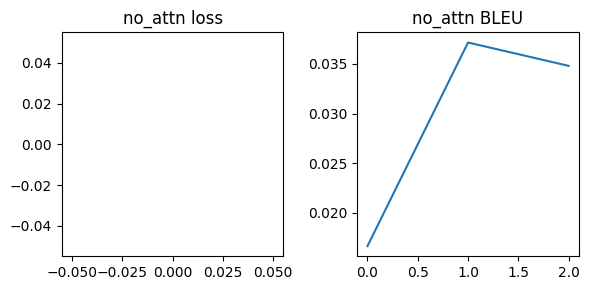

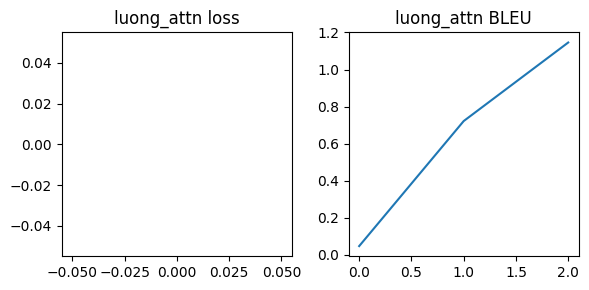

In [4]:
"""
Simplified Seq2Seq RNN (GRU) training for Polish→English translation
Two variants: without attention and with Luong attention.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import sacrebleu
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# ---------- CONFIG ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 3
LR = 1e-3
EMB_DIM = 256
HID_DIM = 512
MAX_LEN = 50
DEBUG_SAMPLES = 10000  # subset for quick testing

PAD, SOS, EOS = "<pad>", "<sos>", "<eos>"
PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2

# ---------- DATA ----------
def tokenize(text):
    return text.lower().strip().split()

class Vocab:
    def __init__(self, texts, min_freq=2, max_size=20000):
        from collections import Counter
        counter = Counter(tok for s in texts for tok in tokenize(s))
        common = [w for w, c in counter.items() if c >= min_freq][:max_size]
        self.itos = [PAD, SOS, EOS] + common
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text):
        toks = tokenize(text)
        ids = [self.stoi.get(SOS, 1)] + [self.stoi.get(t, 0) for t in toks[:MAX_LEN-2]] + [self.stoi.get(EOS, 2)]
        return ids

    def decode(self, ids):
        toks = [self.itos[i] for i in ids if i < len(self.itos) and i not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        return " ".join(toks)

# ---------- DATASET ----------
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.data = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pl, en = self.data[idx]
        src = torch.tensor(self.src_vocab.encode(pl))
        tgt = torch.tensor(self.tgt_vocab.encode(en))
        return src, tgt

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    srcs = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs, tgts

# ---------- MODELS ----------
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        emb = self.emb(src)
        outputs, hidden = self.rnn(emb)
        return outputs, hidden

class DecoderNoAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden):
        emb = self.emb(input_tok.unsqueeze(1))
        out, hidden = self.rnn(emb, hidden)
        logits = self.fc(out.squeeze(1))
        return logits, hidden

class LuongAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim, bias=False)

    def forward(self, dec_h, enc_out):
        attn = torch.bmm(enc_out, self.W(dec_h).unsqueeze(2)).squeeze(2)
        attn_weights = torch.softmax(attn, dim=1)
        ctx = torch.bmm(attn_weights.unsqueeze(1), enc_out).squeeze(1)
        return ctx

class DecoderAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.attn = LuongAttention(hid_dim)
        self.fc = nn.Linear(hid_dim*2, vocab_size)

    def forward(self, input_tok, hidden, enc_out):
        emb = self.emb(input_tok.unsqueeze(1))
        out, hidden = self.rnn(emb, hidden)
        ctx = self.attn(out.squeeze(1), enc_out)
        combined = torch.cat([out.squeeze(1), ctx], dim=1)
        logits = self.fc(combined)
        return logits, hidden

# ---------- TRAIN / EVAL ----------
def train_epoch(encoder, decoder, loader, opt, criterion, attn=False):
    encoder.train(); decoder.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="Train"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        opt.zero_grad()
        enc_out, hidden = encoder(src)
        input_tok = tgt[:, 0]
        loss = 0
        for t in range(1, tgt.size(1)):
            if attn:
                logits, hidden = decoder(input_tok, hidden, enc_out)
            else:
                logits, hidden = decoder(input_tok, hidden)
            loss += criterion(logits, tgt[:, t])
            teacher_force = random.random() < 0.5
            top1 = logits.argmax(1)
            input_tok = tgt[:, t] if teacher_force else top1
        loss /= tgt.size(1)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_bleu(encoder, decoder, loader, src_vocab, tgt_vocab, attn=False):
    encoder.eval(); decoder.eval()
    refs, hyps = [], []
    for src, tgt in tqdm(loader, desc="Eval"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        enc_out, hidden = encoder(src)
        input_tok = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=DEVICE)
        generated = [[] for _ in range(src.size(0))]
        for _ in range(MAX_LEN):
            if attn:
                logits, hidden = decoder(input_tok, hidden, enc_out)
            else:
                logits, hidden = decoder(input_tok, hidden)
            top1 = logits.argmax(1)
            input_tok = top1
            for i in range(src.size(0)):
                generated[i].append(top1[i].item())
        for i in range(src.size(0)):
            hyp = tgt_vocab.decode(generated[i])
            ref = tgt_vocab.decode(tgt[i].tolist())
            hyps.append(hyp)
            refs.append([ref])
    bleu = sacrebleu.corpus_bleu(hyps, list(zip(*refs)))
    return bleu.score

# ---------- MAIN ----------
def main():
    print("Device:", DEVICE)
    ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")
    # pairs = [(ex["translation"]["pl"], ex["translation"]["en"]) for ex in ds["train"][:DEBUG_SAMPLES]]
    pairs = [(ex["translation"]["pl"], ex["translation"]["en"]) for ex in ds["train"].select(range(DEBUG_SAMPLES))]


    src_vocab = Vocab([p[0] for p in pairs])
    tgt_vocab = Vocab([p[1] for p in pairs])
    train_loader = DataLoader(TranslationDataset(pairs[:int(0.9*len(pairs))], src_vocab, tgt_vocab),
                              batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(TranslationDataset(pairs[int(0.9*len(pairs)):], src_vocab, tgt_vocab),
                            batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    results = {}
    for variant, use_attn in [("no_attn", False), ("luong_attn", True)]:
        print("\n=== Training:", variant, "===")
        encoder = Encoder(len(src_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
        decoder = DecoderAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE) if use_attn else DecoderNoAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
        opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=LR)
        criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
        losses, bleus = [], []
        for ep in range(1, EPOCHS+1):
            loss = train_epoch(encoder, decoder, train_loader, opt, criterion, attn=use_attn)
            bleu = evaluate_bleu(encoder, decoder, val_loader, src_vocab, tgt_vocab, attn=use_attn)
            print(f"Epoch {ep}: loss={loss:.3f} BLEU={bleu:.2f}")
            losses.append(loss); bleus.append(bleu)
        results[variant] = (losses, bleus)

    # --- Plot results ---
    for v, (losses, bleus) in results.items():
        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1)
        plt.plot(losses); plt.title(f"{v} loss")
        plt.subplot(1,2,2)
        plt.plot(bleus); plt.title(f"{v} BLEU")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()
